# Synthetic Control — German Reunification & GDP per Capita

Reads in the country-year panel and confirms the treated unit, donor pool, and time span
ahead of building the synthetic control (Abadie, Diamond & Hainmueller 2015).

| | |
|---|---|
| **Treatment** | German reunification, 1990 |
| **Treated unit** | `West Germany` |
| **Outcome** | `gdp` — GDP per capita |
| **Panel** | 17 OECD countries, 1960–2003 |
| **Dataset** | Abadie, Diamond & Hainmueller replication data |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv(Path("../data/raw/germany.csv"))

TREATED_UNIT = "West Germany"
T0           = 1990

donor_pool = sorted(df.loc[df["country"] != TREATED_UNIT, "country"].unique().tolist())

print(f"Treated unit    : {TREATED_UNIT}")
print(f"Donor countries : {len(donor_pool)}")
print(f"Years           : {df['year'].min()}\u2013{df['year'].max()}")
print(f"Shape           : {df.shape}")
df.head()

Treated unit    : West Germany
Donor countries : 16
Years           : 1960–2003
Shape           : (748, 11)


,code,country,year,gdp,infrate,trade,schooling,invest60,invest70,invest80,industry
0,1,USA,1960,2879,NaN,9.693181,43.799999,NaN,NaN,NaN,NaN
1,1,USA,1961,2929,1.075182,9.444655,NaN,NaN,NaN,NaN,NaN
2,1,USA,1962,3103,1.116071,9.429324,NaN,NaN,NaN,NaN,NaN
3,1,USA,1963,3227,1.214128,9.470706,NaN,NaN,NaN,NaN,NaN
4,1,USA,1964,3420,1.308615,9.725879,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   code       748 non-null    int64  
 1   country    748 non-null    str    
 2   year       748 non-null    int64  
 3   gdp        748 non-null    int64  
 4   infrate    727 non-null    float64
 5   trade      646 non-null    float64
 6   schooling  151 non-null    float64
 7   invest60   17 non-null     float64
 8   invest70   17 non-null     float64
 9   invest80   17 non-null     float64
 10  industry   541 non-null    float64
dtypes: float64(7), int64(3), str(1)
memory usage: 64.4 KB


In [4]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


code           0
country        0
year           0
gdp            0
infrate       21
trade        102
schooling    597
invest60     731
invest70     731
invest80     731
industry     207
dtype: int64

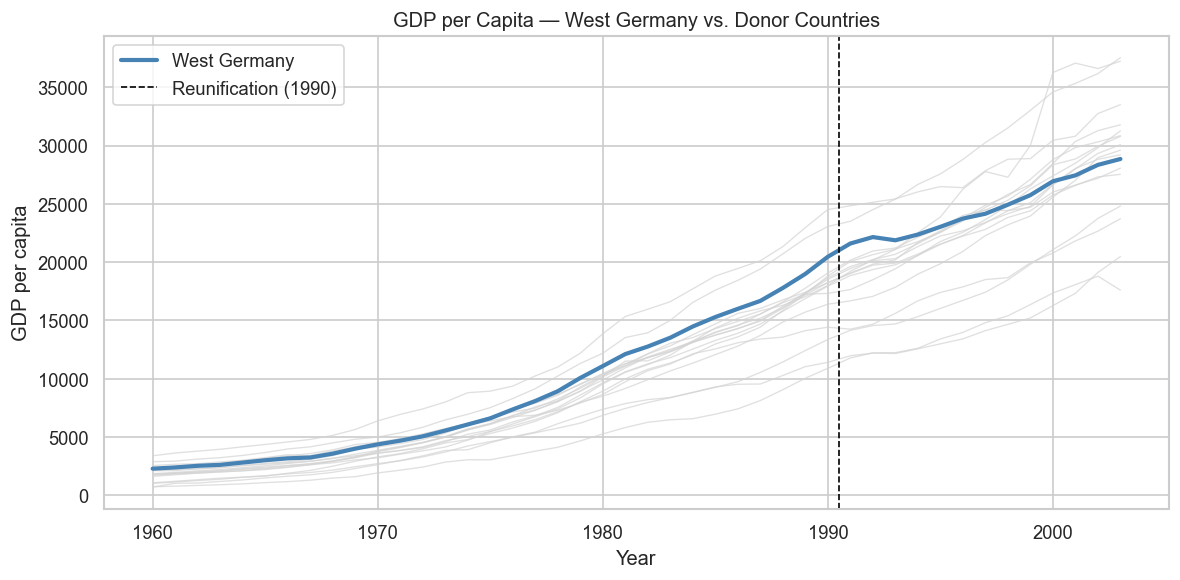

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for country in donor_pool:
    s = df[df["country"] == country]
    ax.plot(s["year"], s["gdp"], color="lightgrey", linewidth=0.8, alpha=0.7)

treated = df[df["country"] == TREATED_UNIT]
ax.plot(treated["year"], treated["gdp"], color="steelblue", linewidth=2.5, label=TREATED_UNIT)
ax.axvline(T0 + 0.5, color="black", linestyle="--", linewidth=1, label=f"Reunification ({T0})")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per capita")
ax.set_title("GDP per Capita \u2014 West Germany vs. Donor Countries")
ax.legend()
plt.tight_layout()
plt.show()